# Attempt 2

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing and augmentation imports
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Classification models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Survival models
from lifelines import CoxPHFitter
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.svm import FastKernelSurvivalSVM

# Evaluation metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

# XAI: LIME and SHAP for Random Forest explanations
import shap
from lime.lime_tabular import LimeTabularExplainer

c:\Users\asank\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# =============================================================================
# 1. Load & preprocess data
# =============================================================================

df = pd.read_csv('S1Data.csv')
df
X = df[['Gender', 'Smoking', 'Diabetes', 'BP', 'Anaemia', 'Age', 'Ejection.Fraction', 'Sodium', 'Creatinine', 'Pletelets', 'CPK']]
y = df['Event']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ----------------------------
# 1.1 Apply Winsorization to numerical features
# ----------------------------
def winsorize_series(s, limits=[0.01, 0.01]):
    return pd.Series(winsorize(s, limits=limits), index=s.index)

for col in ['Age', 'Ejection.Fraction', 'Sodium', 'Creatinine', 'Pletelets', 'CPK']:
    df[col] = winsorize_series(df[col], limits=[0.01, 0.01])

# ----------------------------
# 1.3 Standard Scaling & One Hot Encoding for categorical features
# ----------------------------
numeric_features = ['Age', 'Ejection.Fraction', 'Sodium', 'Creatinine', 'Pletelets', 'CPK']
categorical_features = ['Gender', 'Smoking', 'Diabetes', 'Anaemia']

# Note: For newer versions of scikit-learn use sparse_output instead of sparse
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features)
])

# =============================================================================
# 2. Train-Test Split and Augmentation with Multiple Techniques
# =============================================================================

# Classification target
X = df[numeric_features + categorical_features]
y_class = df['Event']

# For survival analysis, create a structured array
y_surv = np.array([(bool(event), time) for event, time in zip(df['Event'], df['TIME'])],
                  dtype=[('Event', 'bool'), ('TIME', 'float')])

# Split the data (stratify for classification)
X_train, X_test, y_train_class, y_test_class, y_train_surv, y_test_surv = train_test_split(
    X, y_class, y_surv, test_size=0.2, random_state=42, stratify=y_class
)

# Apply preprocessing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# ----------------------------
# 2.1 Data Augmentation: Multiple Techniques
# ----------------------------
n_numeric = len(numeric_features)

# List to store all augmented versions
augmented_data = []
augmented_labels = []

# 1. Original data
augmented_data.append(X_train_proc)
augmented_labels.append(y_train_class)

# 2. Gaussian noise with different scales
noise_scales = [0.01, 0.02, 0.05]
for scale in noise_scales:
    noise = np.random.normal(0, scale, size=X_train_proc.shape)
    # Only apply noise to numeric columns
    noise[:, n_numeric:] = 0  # Zero out noise for categorical columns
    augmented_version = X_train_proc + noise
    augmented_data.append(augmented_version)
    augmented_labels.append(y_train_class)

# 3. Random scaling of numeric features
scaling_factors = [0.95, 1.05]  # ±5% scaling
for factor in scaling_factors:
    scaled_version = X_train_proc.copy()
    scaled_version[:, :n_numeric] *= factor
    augmented_data.append(scaled_version)
    augmented_labels.append(y_train_class)

# 4. Combine noise and scaling
for scale in noise_scales[:1]:  # Use only the smallest noise scale for combinations
    for factor in scaling_factors:
        combined_version = X_train_proc.copy()
        # Apply scaling
        combined_version[:, :n_numeric] *= factor
        # Apply noise
        noise = np.random.normal(0, scale, size=X_train_proc.shape)
        noise[:, n_numeric:] = 0  # Zero out noise for categorical columns
        combined_version += noise
        augmented_data.append(combined_version)
        augmented_labels.append(y_train_class)

# Combine all augmented versions
X_train_combined = np.concatenate(augmented_data, axis=0)
y_train_class_combined = np.concatenate(augmented_labels, axis=0)

print("Original training samples:", len(X_train))
print("Augmented training samples:", len(X_train_combined))

# For survival, we use the preprocessed training data as is
X_train_surv = X_train_proc

Original training samples: 239
Augmented training samples: 1912


In [10]:
X_train_combined.shape

(1912, 10)

In [11]:
# =============================================================================
# 3. Model Implementation
# =============================================================================

# ----------------------------
# 3.1 Classification Models
# ----------------------------

# --- Tabular Transformer (dummy example with a simple NN) ---
def create_tabular_transformer(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

input_dim = X_train_combined.shape[1]
tab_transformer = create_tabular_transformer(input_dim)
history_tt = tab_transformer.fit(X_train_combined, y_train_class_combined, epochs=20, batch_size=32,
                                 validation_split=0.2, verbose=0)

# --- Random Forest ---
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_combined, y_train_class_combined)

# --- XGBoost ---
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_combined, y_train_class_combined)

# --- AdaBoost ---
ada_clf = AdaBoostClassifier(random_state=42)
ada_clf.fit(X_train_combined, y_train_class_combined)

# --- Extra Trees ---
et_clf = ExtraTreesClassifier(random_state=42)
et_clf.fit(X_train_combined, y_train_class_combined)

# --- Gradient Boosting ---
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_combined, y_train_class_combined)

# ----------------------------
# 3.2 Survival Models
# ----------------------------

# Create DataFrames for lifelines
X_train_df = pd.DataFrame(X_train_proc, columns=[f'feat_{i}' for i in range(X_train_proc.shape[1])])
X_test_df = pd.DataFrame(X_test_proc, columns=[f'feat_{i}' for i in range(X_test_proc.shape[1])])
X_train_df['TIME'] = [t for (_, t) in y_train_surv]
X_train_df['Event'] = [e for (e, _) in y_train_surv]
X_test_df['TIME'] = [t for (_, t) in y_test_surv]
X_test_df['Event'] = [e for (e, _) in y_test_surv]

# --- Cox Proportional Hazards Model ---
cph = CoxPHFitter()
cph.fit(X_train_df, duration_col='TIME', event_col='Event')

# --- Random Survival Forest ---
rsf = RandomSurvivalForest(n_estimators=100, random_state=42)
rsf.fit(X_train_surv, y_train_surv)

# --- Extra Survival Trees (using RSF as proxy) ---
extra_surv_trees = RandomSurvivalForest(n_estimators=100, random_state=42)
extra_surv_trees.fit(X_train_surv, y_train_surv)

# --- Survival SVM ---
# Increase max_iter to address convergence issues
surv_svm = FastKernelSurvivalSVM(max_iter=10000, random_state=42)
surv_svm.fit(X_train_surv, y_train_surv)

c:\Users\asank\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:35:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FastKernelSurvivalSVM(max_iter=10000, optimizer='rbtree', random_state=42)

Tabular Transformer:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Tabular Transformer Accuracy: 0.650, AUROC: 0.632
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        41
           1       0.45      0.53      0.49        19

    accuracy                           0.65        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.67      0.65      0.66        60

Tabular Transformer Accuracy: 0.650, AUROC: 0.632
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        41
           1       0.45      0.53      0.49        19

    accuracy                           0.65        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.67      0.65      0.66        60



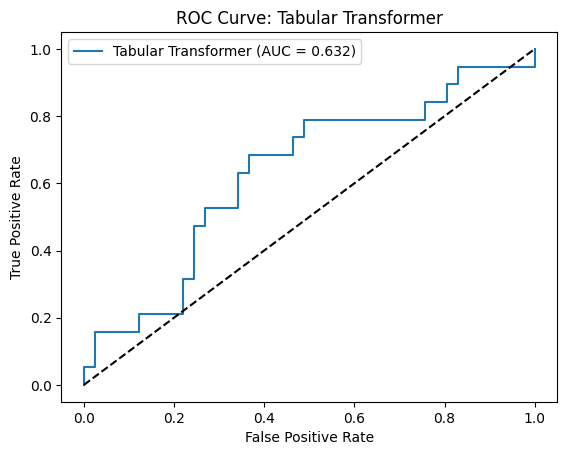

Random Forest:
Random Forest Accuracy: 0.767, AUROC: 0.789
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.62      0.68      0.65        19

    accuracy                           0.77        60
   macro avg       0.73      0.74      0.74        60
weighted avg       0.77      0.77      0.77        60



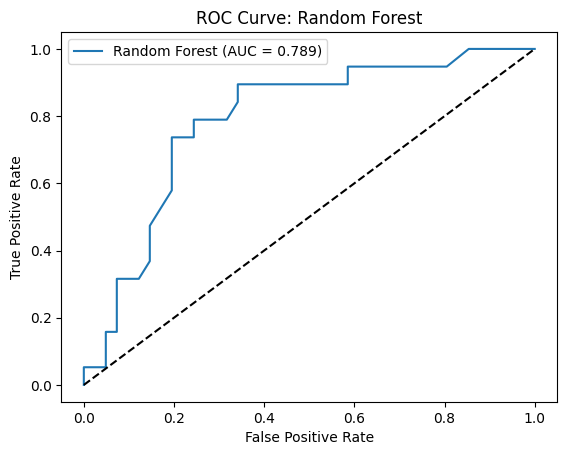

XGBoost:
XGBoost Accuracy: 0.683, AUROC: 0.745
              precision    recall  f1-score   support

           0       0.76      0.78      0.77        41
           1       0.50      0.47      0.49        19

    accuracy                           0.68        60
   macro avg       0.63      0.63      0.63        60
weighted avg       0.68      0.68      0.68        60



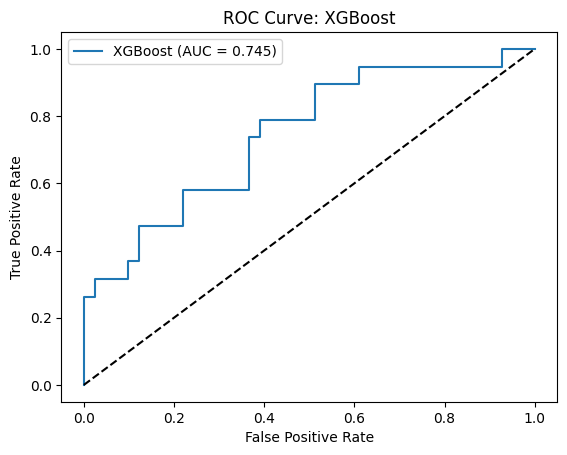

AdaBoost:
AdaBoost Accuracy: 0.750, AUROC: 0.772
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        41
           1       0.64      0.47      0.55        19

    accuracy                           0.75        60
   macro avg       0.71      0.68      0.69        60
weighted avg       0.74      0.75      0.74        60



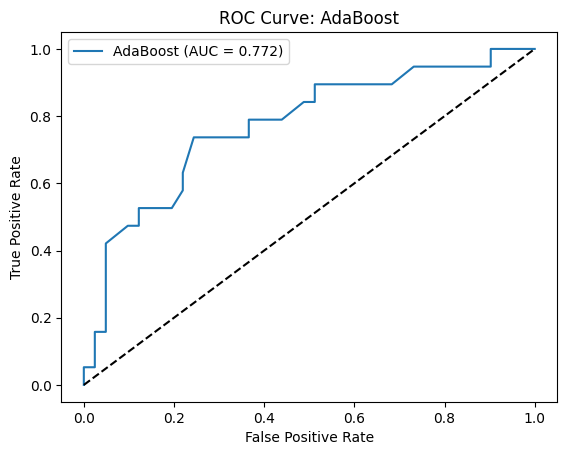

Extra Trees:
Extra Trees Accuracy: 0.700, AUROC: 0.746
              precision    recall  f1-score   support

           0       0.74      0.85      0.80        41
           1       0.54      0.37      0.44        19

    accuracy                           0.70        60
   macro avg       0.64      0.61      0.62        60
weighted avg       0.68      0.70      0.68        60



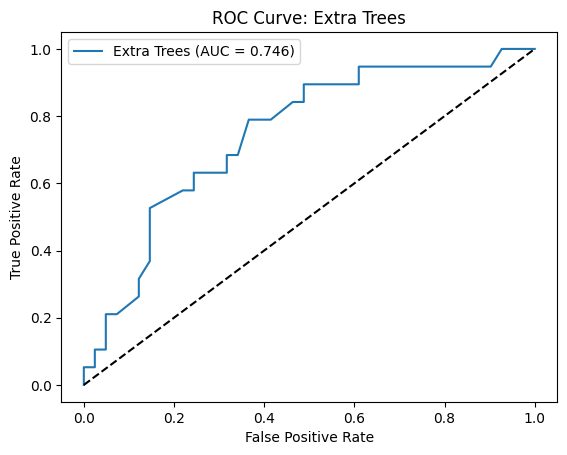

Gradient Boosting:
Gradient Boosting Accuracy: 0.667, AUROC: 0.778
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        41
           1       0.48      0.53      0.50        19

    accuracy                           0.67        60
   macro avg       0.62      0.63      0.62        60
weighted avg       0.68      0.67      0.67        60



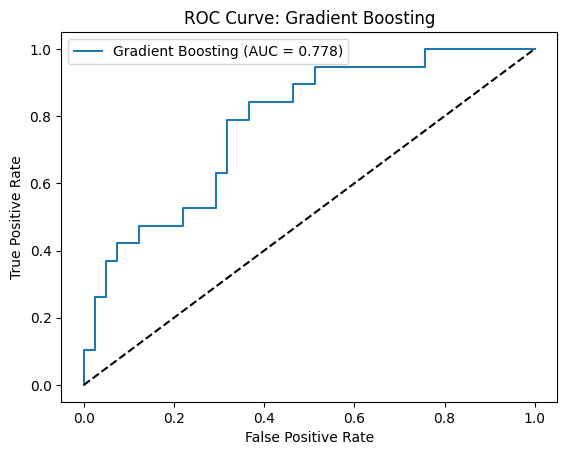

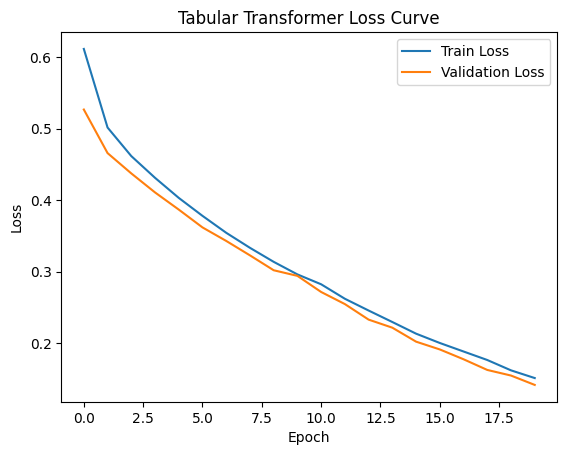

In [13]:
# =============================================================================
# 4. Model Evaluation
# =============================================================================

# ----------------------------
# 4.1 Classification Evaluation
# ----------------------------
def evaluate_classification(model, X_test, y_test, model_name="Model"):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For Keras models
        y_proba = model.predict(X_test).ravel()
        y_proba = np.clip(y_proba, 0, 1)
    y_pred = (y_proba > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"{model_name} Accuracy: {acc:.3f}, AUROC: {auc:.3f}")
    print(classification_report(y_test, y_pred))

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.show()

print("Tabular Transformer:")
evaluate_classification(tab_transformer, X_test_proc, y_test_class, model_name="Tabular Transformer")

print("Random Forest:")
evaluate_classification(rf_clf, X_test_proc, y_test_class, model_name="Random Forest")

print("XGBoost:")
evaluate_classification(xgb_clf, X_test_proc, y_test_class, model_name="XGBoost")

print("AdaBoost:")
evaluate_classification(ada_clf, X_test_proc, y_test_class, model_name="AdaBoost")

print("Extra Trees:")
evaluate_classification(et_clf, X_test_proc, y_test_class, model_name="Extra Trees")

print("Gradient Boosting:")
evaluate_classification(gb_clf, X_test_proc, y_test_class, model_name="Gradient Boosting")

# Loss curve for Tabular Transformer
plt.figure()
plt.plot(history_tt.history['loss'], label='Train Loss')
plt.plot(history_tt.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tabular Transformer Loss Curve")
plt.legend()
plt.show()

In [14]:
# ----------------------------
# 4.2 Survival Evaluation
# ----------------------------
c_index_cox = cph.concordance_index_
print(f"Cox PH Concordance Index: {c_index_cox:.3f}")

def evaluate_survival(model, X_test, y_test, model_name="Survival Model"):
    surv_pred = model.predict(X_test)
    result = concordance_index_censored(
        [e for (e, _) in y_test],
        [t for (_, t) in y_test],
        -surv_pred
    )
    print(f"{model_name} Concordance Index: {result[0]:.3f}")

evaluate_survival(rsf, X_test_proc, y_test_surv, model_name="Random Survival Forest")
evaluate_survival(extra_surv_trees, X_test_proc, y_test_surv, model_name="Extra Survival Trees")
evaluate_survival(surv_svm, X_test_proc, y_test_surv, model_name="Survival SVM")


Cox PH Concordance Index: 0.738
Random Survival Forest Concordance Index: 0.247
Extra Survival Trees Concordance Index: 0.247
Survival SVM Concordance Index: 0.364


X_test_proc shape: (60, 10)


<Figure size 640x480 with 0 Axes>

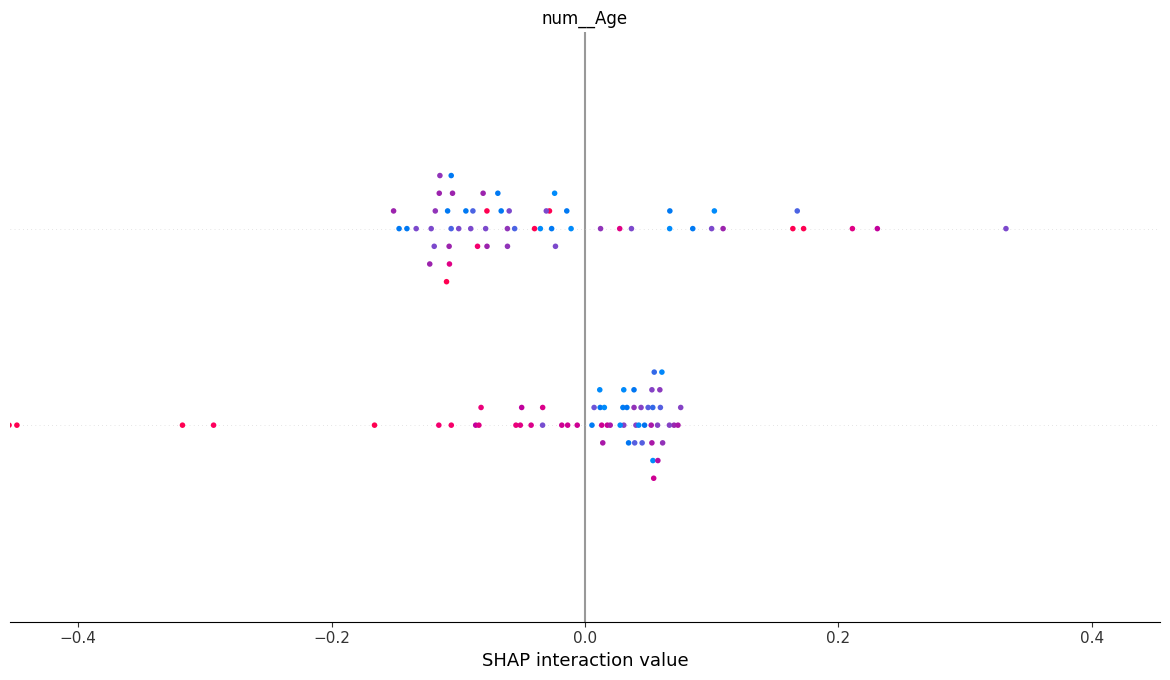


Feature Importances:
--------------------------------------------------
num__Sodium <= -0.58          :    0.134
-0.71 < num__Ejection.Fraction <= -0.03:   -0.076
-0.04 < num__Age <= 0.72      :   -0.070
0.00 < cat__Anaemia_1 <= 1.00 :    0.052
-0.51 < num__Creatinine <= -0.32:   -0.049
0.00 < cat__Gender_1 <= 1.00  :   -0.032
0.00 < cat__Diabetes_1 <= 1.00:    0.029
0.01 < num__Pletelets <= 0.49 :   -0.029
cat__Smoking_1 <= 0.00        :   -0.007
num__CPK > 0.02               :   -0.003

Prediction Probabilities:
Class 0: 0.700
Class 1: 0.300


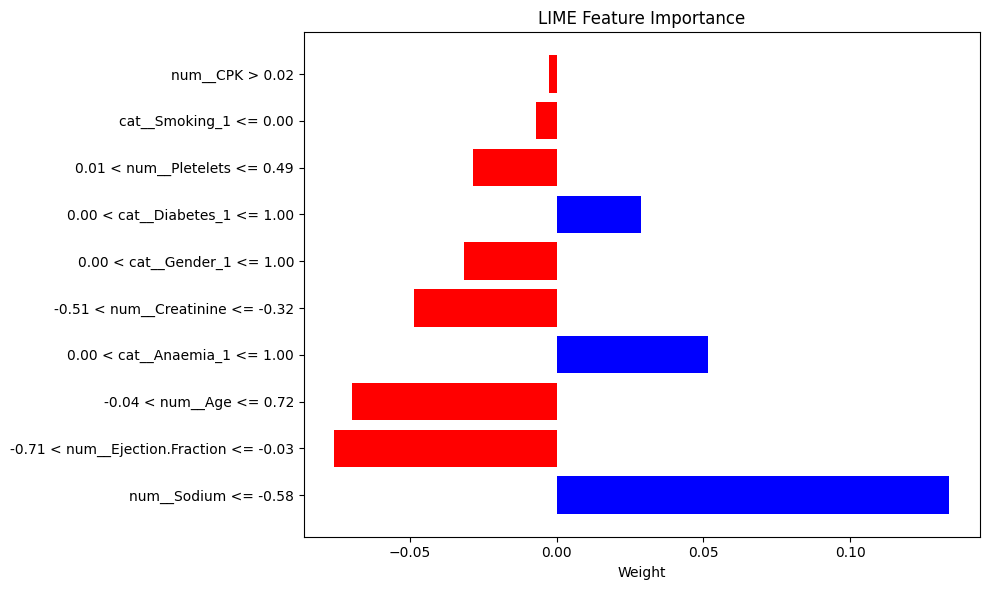

In [26]:
# =============================================================================
# 5. Explainable AI for Random Forest (LIME and SHAP)
# =============================================================================

# ----------------------------
# 5.1 SHAP explanations
# ----------------------------
explainer_shap = shap.TreeExplainer(rf_clf)
shap_values = explainer_shap.shap_values(X_test_proc)

# Check shapes to decide which set of SHAP values to use
print("X_test_proc shape:", X_test_proc.shape)
if isinstance(shap_values, list):
    print("shap_values[0].shape:", shap_values[0].shape)
    print("shap_values[1].shape:", shap_values[1].shape)
    # Use the one that matches the number of features
    if shap_values[0].shape[1] == X_test_proc.shape[1]:
        selected_shap = shap_values[0]
    elif shap_values[1].shape[1] == X_test_proc.shape[1]:
        selected_shap = shap_values[1]
    else:
        selected_shap = shap_values[0]
else:
    selected_shap = shap_values

shap.summary_plot(selected_shap, X_test_proc, feature_names=preprocessor.get_feature_names_out())

# ----------------------------
# 5.2 LIME explanations
# ----------------------------
def show_lime_explanation(exp):
    """Display LIME explanation without IPython dependency"""
    local_exp = exp.as_list()
    
    # Print feature importance
    print("\nFeature Importances:")
    print("-" * 50)
    for feat, weight in local_exp:
        print(f"{feat:30s}: {weight:>8.3f}")
    
    # Print prediction
    if exp.predict_proba is not None:
        probs = exp.predict_proba
        print("\nPrediction Probabilities:")
        print(f"Class 0: {probs[0]:.3f}")
        print(f"Class 1: {probs[1]:.3f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    features = [x[0] for x in local_exp]
    weights = [x[1] for x in local_exp]
    
    colors = ['red' if w < 0 else 'blue' for w in weights]
    plt.barh(range(len(features)), weights, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('Weight')
    plt.title('LIME Feature Importance')
    plt.tight_layout()
    plt.show()

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_combined,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['0', '1'],
    mode='classification'
)

# Explain first instance
i = 0  # Index of the instance to explain
exp = lime_explainer.explain_instance(X_test_proc[i], rf_clf.predict_proba, num_features=10)
show_lime_explanation(exp)